In [30]:
#import statements
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import matplotlib.pyplot as plt
from torchinfo import summary
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
import nilearn.image
import nilearn.plotting
import copy
from torch.utils.data import random_split, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, r2_score
from sklearn.preprocessing import label_binarize
from pathlib import Path
from scipy import signal
import mne
from mne.preprocessing import ICA
from mne_icalabel.iclabel import iclabel_label_components
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger

In [32]:
class EEGSegmentDataset(Dataset):
    def __init__(self, parquet_dir, pca_targets, n_pca_components, n_segments,
                 subject_ids, target_mean=None, target_std=None):
        self.n_segments = n_segments
        paths = {p.stem: p for p in Path(parquet_dir).glob("*.parquet")}
        ids = sorted(set(paths) & set(pca_targets.index.astype(str)) & {str(s) for s in subject_ids})
        self.subjects = ids
        self.subj_to_idx = {s: i for i, s in enumerate(ids)}
        
        raw = np.stack([pca_targets.loc[s].to_numpy(dtype=np.float32)[:n_pca_components]
                        for s in ids])
        if target_mean is None:
            target_mean = raw.mean(0).astype(np.float32)
            target_std = (raw.std(0) + 1e-8).astype(np.float32)
        self.target_mean, self.target_std = target_mean, target_std
        self.targets = {s: ((raw[i] - target_mean) / target_std).astype(np.float32)
                        for i, s in enumerate(ids)}

        # Preload each subject once into memory as (n_seg, n_ch, 2560) float32
        self.cache = {}
        for i, s in enumerate(ids):
            df = (pd.read_parquet(paths[s],
                                  columns=["channel_name", "segment", "segment_index"])
                    .sort_values(["segment_index", "channel_name"]))
            n_seg = df["segment_index"].nunique()
            n_ch = df["channel_name"].nunique()
            arr = np.stack([np.pad(np.asarray(a, dtype=np.float32)[:2560], (0, max(0, 2560 - len(a))))
                            for a in df["segment"]])
            self.cache[s] = arr.reshape(n_seg, n_ch, 2560)
            if (i + 1) % 100 == 0 or i + 1 == len(ids):
                print(f"  loaded {i+1}/{len(ids)}", flush=True)

        self.manifest = [s for s in ids if len(self.cache[s]) >= n_segments]

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        subject_id = self.manifest[idx]
        arr = self.cache[subject_id][:self.n_segments]               # (n_seg, n_ch, L)
        window = arr.transpose(1, 0, 2).reshape(arr.shape[1], -1)    # (n_ch, n_seg*L)
        return (torch.from_numpy(np.ascontiguousarray(window)),
                torch.from_numpy(self.targets[subject_id]),
                self.subj_to_idx[subject_id])

In [33]:
pca_vals_raw = pd.read_parquet("model_data/matched_pca_vectors.parquet")
pca_vals = pd.DataFrame(
    np.stack(pca_vals_raw["vector"].to_numpy()),
    index=pca_vals_raw["subject"].astype(str),
)

In [34]:
all_subjects = np.array(sorted(
    set(pca_vals.index) & {p.stem for p in Path("model_data/non_ica").glob("*.parquet")}
))
shuffled = np.random.default_rng(42).permutation(all_subjects)
n_train = int(0.8 * len(shuffled))
train_subjects, test_subjects = shuffled[:n_train], shuffled[n_train:]
N_PCA, N_SEG = 1, 10

In [35]:
train_ds = EEGSegmentDataset("model_data/non_ica", pca_vals,
                             n_pca_components=N_PCA, n_segments=N_SEG,
                             subject_ids=train_subjects)
test_ds  = EEGSegmentDataset("model_data/non_ica", pca_vals,
                             n_pca_components=N_PCA, n_segments=N_SEG,
                             subject_ids=test_subjects,
                             target_mean=train_ds.target_mean,
                             target_std=train_ds.target_std)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0)

  loaded 100/1264
  loaded 200/1264
  loaded 300/1264
  loaded 400/1264
  loaded 500/1264
  loaded 600/1264
  loaded 700/1264
  loaded 800/1264
  loaded 900/1264
  loaded 1000/1264
  loaded 1100/1264
  loaded 1200/1264
  loaded 1264/1264
  loaded 100/316
  loaded 200/316
  loaded 300/316
  loaded 316/316


In [36]:
class EEGTemporalCNN(nn.Module):
    def __init__(self, n_channels, n_outputs, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 32, 128, padding=64, bias=False),
            nn.BatchNorm1d(32), nn.GELU(), nn.AvgPool1d(4), nn.Dropout(dropout),
            nn.Conv1d(32, 64, 16, padding=8, bias=False),
            nn.BatchNorm1d(64), nn.GELU(), nn.AvgPool1d(4), nn.Dropout(dropout),
            nn.Conv1d(64, 128, 8, padding=4, bias=False),
            nn.BatchNorm1d(128), nn.GELU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(128, n_outputs),
        )

    def forward(self, x):
        return self.net(x)

In [46]:
class EEGRegressor(pl.LightningModule):
    def __init__(self, n_channels, n_outputs, lr=3e-4):
        super().__init__()
        self.save_hyperparameters()
        self.net = EEGTemporalCNN(n_channels, n_outputs)
        self.loss = nn.MSELoss()
        self._train_buf = []
        self._val_buf = []

    @staticmethod
    def _agg_r2(buf):
        preds = torch.cat([b[0] for b in buf]).numpy()
        targets = torch.cat([b[1] for b in buf]).numpy()
        subj = torch.cat([b[2] for b in buf]).numpy()
        agg_p, agg_t = [], []
        for s in np.unique(subj):
            m = subj == s
            agg_p.append(preds[m].mean(0))
            agg_t.append(targets[m].mean(0))
        agg_p, agg_t = np.stack(agg_p), np.stack(agg_t)
        if agg_p.shape[0] < 2:
            return np.full(agg_p.shape[1], np.nan)
        return r2_score(agg_t, agg_p, multioutput="raw_values")

    def training_step(self, batch, _):
        x, y, subj = batch
        pred = self.net(x)
        loss = self.loss(pred, y)
        self._train_buf.append((pred.detach().cpu(), y.detach().cpu(), subj.detach().cpu()))
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        r2 = self._agg_r2(self._train_buf)
        for i, v in enumerate(r2):
            self.log(f"train_r2_pc{i+1}", float(v))
        self.log("train_r2_mean", float(r2.mean()), prog_bar=True)
        self._train_buf.clear()

    def validation_step(self, batch, _):
        x, y, subj = batch
        pred = self.net(x)
        self._val_buf.append((pred.detach().cpu(), y.detach().cpu(), subj.detach().cpu()))
        self.log("val_loss", self.loss(pred, y), on_step=True, on_epoch=True, prog_bar=True)

    def on_validation_epoch_end(self):
        r2 = self._agg_r2(self._val_buf)
        for i, v in enumerate(r2):
            self.log(f"val_r2_pc{i+1}", float(v))
        self.log("val_r2_mean", float(r2.mean()), prog_bar=True)
        self._val_buf.clear()

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-2)

In [47]:
logger = TensorBoardLogger(save_dir="model_data", name="lightning_logs")
v = logger.version
ckpt_dir = Path("model_data/models")

In [48]:
best_ckpt = ModelCheckpoint(
    dirpath=ckpt_dir,
    monitor="val_r2_mean",
    mode="max",
    filename=f"best-v{v}",
    save_top_k=1,
    save_last=False,
)
last_ckpt = ModelCheckpoint(
    dirpath=ckpt_dir,
    monitor="epoch",
    mode="max",
    filename=f"last-v{v}",
    save_top_k=1,
)

In [49]:
model = EEGRegressor(n_channels=8, n_outputs=N_PCA)

In [50]:
trainer = pl.Trainer(
    max_epochs=500,
    accelerator="mps",
    devices=1,
    log_every_n_steps=1,
    callbacks=[best_ckpt, last_ckpt],
    logger=logger,
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [51]:
trainer.fit(model, train_loader, test_loader)

/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/model_data/models exists and is not empty.

  | Name | Type           | Params | Mode  | FLOPs
--------------------------------------------------------
0 | net  | EEGTemporalCNN | 131 K  | train | 0    
1 | loss | MSELoss        | 0      | train | 0    
--------------------------------------------------------
131 K     Trainable params
0         Non-trainable params
131 K     Total params
0.527     Total estimated model params size (MB)
19        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Sanity Checking DataLoader 0:  50%|█████     | 1/2 [00:00<00:00, 11.68it/s]

/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 499: 100%|██████████| 20/20 [00:03<00:00,  5.67it/s, v_num=7, train_loss_step=0.265, val_loss_step=1.240, val_loss_epoch=1.040, val_r2_mean=-0.204, train_loss_epoch=0.329, train_r2_mean=0.684] 

`Trainer.fit` stopped: `max_epochs=500` reached.


Epoch 499: 100%|██████████| 20/20 [00:03<00:00,  5.62it/s, v_num=7, train_loss_step=0.265, val_loss_step=1.240, val_loss_epoch=1.040, val_r2_mean=-0.204, train_loss_epoch=0.329, train_r2_mean=0.684]


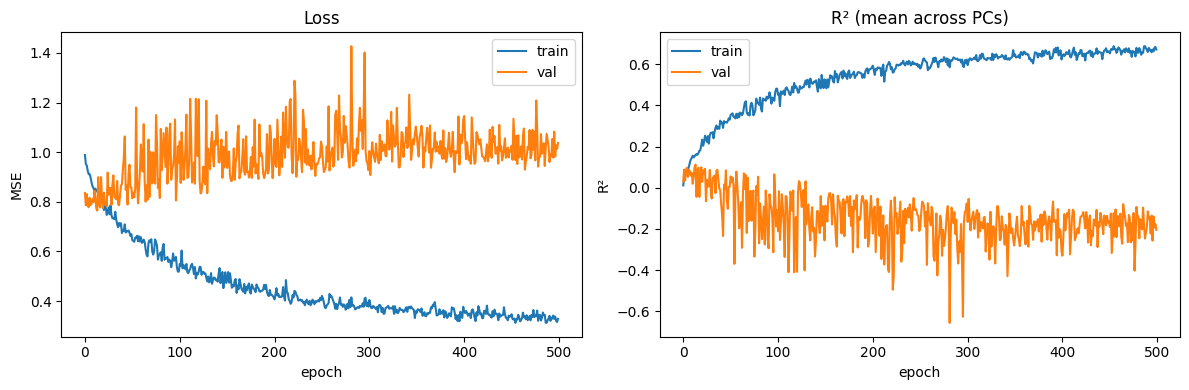

model_data/lightning_logs/version_7


In [52]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

log_dir = sorted(Path("model_data/lightning_logs").glob("version_*"))[-1]
ea = EventAccumulator(str(log_dir), size_guidance={"scalars": 0}); ea.Reload()

def series(tag):
    vals = [e.value for e in ea.Scalars(tag)] if tag in ea.Tags()["scalars"] else []
    return list(range(len(vals))), vals

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for tag, lab in [("train_loss_epoch", "train"), ("val_loss_epoch", "val")]:
    axes[0].plot(*series(tag), label=lab)
axes[0].set(xlabel="epoch", ylabel="MSE", title="Loss"); axes[0].legend()
for tag, lab in [("train_r2_mean", "train"), ("val_r2_mean", "val")]:
    axes[1].plot(*series(tag), label=lab)
axes[1].set(xlabel="epoch", ylabel="R²", title="R² (mean across PCs)"); axes[1].legend()
plt.tight_layout(); plt.show()
print(log_dir)